# Statistical Properties 04 — Cointegration

**Goal:** Test whether multiple price series (EUR Scryfall, EUR Cardmarket, USD TCGPlayer) are cointegrated — i.e. whether, despite local deviations, they converge to a shared long-run equilibrium.

**Tables:** gold_price_features (columns: eur, cardmarket_eur, tcgplayer_usd)

**Methods:**
- Engle-Granger test (two-step cointegration test for pairs)
- Johansen test (multivariate, for more than 2 series)
- Visualization: spread between markets (residuals from the cointegrating relationship)

**Why this matters:**
- If EUR and cardmarket_EUR are cointegrated → the spread between them is a stationary signal → it can be modelled as a feature (spread = short-term arbitrage opportunity)
- If series are NOT cointegrated → they are independent processes → price levels cannot be directly compared
- Cointegration EUR↔USD → the model can cross-validate EUR predictions against USD

⚠️ **Pre-condition:** Cointegration is only meaningful between I(1) series. Check results from 02_stationarity.ipynb — if series are I(0), cointegration does not apply (I(0) series are already stationary by definition).

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller

In [2]:
gold_connection = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

In [3]:
# Pre-condition: log-prices are typically I(1) — confirmed in 02_stationarity.ipynb.
# Cointegration only applies to I(1) series; I(0) series are already stationary.

# Daily median per market — aggregating across all cards gives a stable representative
# series and avoids the noise of individual card prices.
market = gold_connection.execute("""
    SELECT
        snapshot_date,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY eur)            AS eur,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY cardmarket_eur) AS cardmarket_eur,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY tcgplayer_usd)  AS tcgplayer_usd,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY usd)            AS usd_scryfall
    FROM gold_price_features
    WHERE eur IS NOT NULL
    GROUP BY snapshot_date
    ORDER BY snapshot_date
""").df()

market["snapshot_date"] = pd.to_datetime(market["snapshot_date"])
market = market.set_index("snapshot_date")

print("Data availability per market:")
for col, label in [
    ("eur", "EUR Scryfall    "),
    ("cardmarket_eur", "Cardmarket EUR  "),
    ("tcgplayer_usd", "USD TCGPlayer   "),
    ("usd_scryfall", "USD Scryfall    "),
]:
    n = market[col].notna().sum()
    print(f"  {label}: {n:3d} days")

print(f"\nDate range: {market.index.min().date()} → {market.index.max().date()}")

Data availability per market:
  EUR Scryfall    :  36 days
  Cardmarket EUR  :  36 days
  USD TCGPlayer   :  36 days
  USD Scryfall    :  36 days

Date range: 2026-05-26 → 2026-07-09


## 1. Visualization — Spread Between Markets

**Method:** Line chart of log(EUR) and log(cardmarket_EUR) on the same axis. Separate panel: spread = log(EUR) - log(cardmarket_EUR).

**Why:** If series are cointegrated, the spread should be stationary (oscillating around a constant). A drifting spread = no cointegration or a structural break.

**What to look for:**
- Is the spread bounded? → suggests cointegration
- Does the spread oscillate around zero? → both markets are in equilibrium
- Long periods of positive/negative spread → Scryfall lags Cardmarket or vice versa

**Implicit FX:** If we have EUR and USD, spread = log(EUR) - log(USD) + log(FX_EUR_USD). If spread is constant → markets are synchronised after FX adjustment.

In [4]:
log_eur = np.log1p(market["eur"])
log_cm_eur = np.log1p(market["cardmarket_eur"])

# Use TCGPlayer USD if it has ≥5 observations (preferred); fall back to Scryfall USD.
usd_col = (
    "tcgplayer_usd" if market["tcgplayer_usd"].notna().sum() >= 5 else "usd_scryfall"
)
log_usd = np.log1p(market[usd_col])
print(f"USD source used: {usd_col} (n={market[usd_col].notna().sum()} days)")

n_obs = len(market)
print(f"\nAvailable observations: n={n_obs} snapshots")
if n_obs < 20:
    print(f"  ⚠ Insufficient data for cointegration tests (need ≥20, have {n_obs}).")
    print("  Spread visualisation and descriptive statistics are still possible;")
    print("  Engle-Granger and ADF tests will be skipped until data accumulates.")

USD source used: tcgplayer_usd (n=36 days)

Available observations: n=36 snapshots


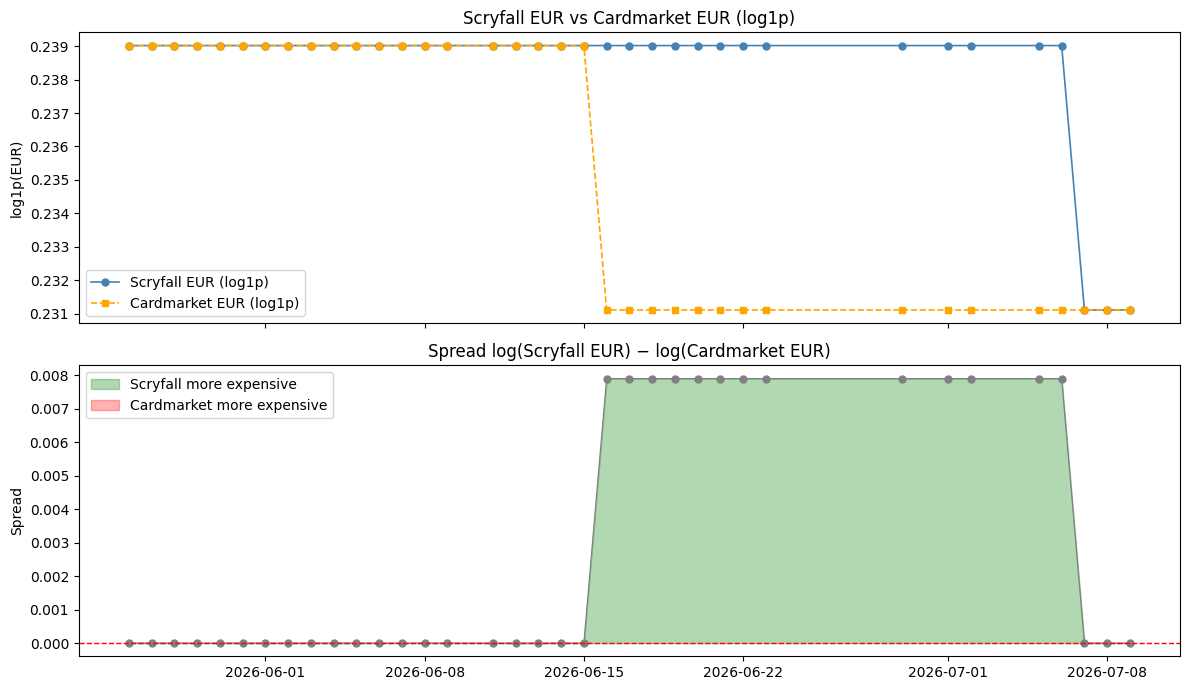


Spread EUR−Cardmarket statistics (n=36 days):
  mean = 0.0029
  std  = 0.0039
  min  = 0.0000, max = 0.0079
  % days with spread >10%: 0.0%


In [5]:
# Spread = log(Scryfall EUR) − log(Cardmarket EUR).
# If the two series are cointegrated, this spread is stationary — it oscillates
# around a constant mean rather than drifting.
spread_eur = (log_eur - log_cm_eur).dropna()

if len(spread_eur) >= 2:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    ax1.plot(
        log_eur.index,
        log_eur,
        "o-",
        label="Scryfall EUR (log1p)",
        color="steelblue",
        linewidth=1.2,
        markersize=5,
    )
    ax1.plot(
        log_cm_eur.index,
        log_cm_eur,
        "s--",
        label="Cardmarket EUR (log1p)",
        color="orange",
        linewidth=1.2,
        markersize=5,
    )
    ax1.set_ylabel("log1p(EUR)")
    ax1.set_title("Scryfall EUR vs Cardmarket EUR (log1p)")
    ax1.legend()

    ax2.plot(
        spread_eur.index, spread_eur, "o-", color="gray", linewidth=0.9, markersize=5
    )
    ax2.axhline(0, color="red", linestyle="--", linewidth=1)
    ax2.fill_between(
        spread_eur.index,
        spread_eur,
        0,
        where=(spread_eur > 0),
        color="green",
        alpha=0.3,
        label="Scryfall more expensive",
    )
    ax2.fill_between(
        spread_eur.index,
        spread_eur,
        0,
        where=(spread_eur < 0),
        color="red",
        alpha=0.3,
        label="Cardmarket more expensive",
    )
    ax2.set_ylabel("Spread")
    ax2.set_title("Spread log(Scryfall EUR) − log(Cardmarket EUR)")
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f"\nSpread EUR−Cardmarket statistics (n={len(spread_eur)} days):")
    print(f"  mean = {spread_eur.mean():.4f}")
    print(f"  std  = {spread_eur.std():.4f}")
    print(f"  min  = {spread_eur.min():.4f}, max = {spread_eur.max():.4f}")
    threshold = np.log(1.10)
    pct_big = (spread_eur.abs() > threshold).mean() * 100
    print(f"  % days with spread >10%: {pct_big:.1f}%")
else:
    print("Insufficient observations to plot the spread.")

## 2. Engle-Granger Test — Pairwise Cointegration

**Method:** statsmodels.tsa.stattools.coint(y0, y1) — tests residuals of regression y0 ~ y1 for stationarity.

**H₀:** Series are not cointegrated.
**H₁:** Series are cointegrated.

**Interpretation:** p < 0.05 → reject H₀ → series are cointegrated → long-run equilibrium exists.

**Test pairs:**
1. log(EUR_Scryfall) ~ log(Cardmarket_EUR)
2. log(EUR_Scryfall) ~ log(USD_TCGPlayer)
3. log(Cardmarket_EUR) ~ log(USD_TCGPlayer)

⚠️ **Requirements:** Minimum ~20 observations for a reliable test. At n=3 (current pipeline) → sample too small. Market-wide daily medians are used.

**If pair is cointegrated:** Residuals from the OLS regression = stationary spread → can be used as a feature (Error Correction Model).

In [6]:
MIN_OBS = 20

pairs_def = [
    ("EUR Scryfall", "Cardmarket EUR", log_eur, log_cm_eur),
    ("EUR Scryfall", f"USD ({usd_col})", log_eur, log_usd),
    ("Cardmarket EUR", f"USD ({usd_col})", log_cm_eur, log_usd),
]

# Run Engle-Granger for each pair — only for series with ≥20 observations.
# At n<20 the ADF test on residuals is unreliable (too few data points for
# the asymptotic distribution to hold).
eg_results = []
for name1, name2, s1_raw, s2_raw in pairs_def:
    pair_df = pd.DataFrame({"s1": s1_raw, "s2": s2_raw}).dropna()
    n = len(pair_df)
    if n < MIN_OBS:
        print(
            f"  {name1} ~ {name2}: n={n} < {MIN_OBS} — skipped (insufficient history)"
        )
        continue
    t_stat, p_val, cv = coint(pair_df["s1"], pair_df["s2"])
    cointegrated = "YES" if p_val < 0.05 else "NO"
    eg_results.append(
        {
            "Pair": f"{name1} ~ {name2}",
            "n": n,
            "t-stat": round(t_stat, 4),
            "p-value": round(p_val, 4),
            "CV 5%": round(cv[1], 4),
            "Cointegrated": cointegrated,
        }
    )
    print(
        f"  {name1} ~ {name2} (n={n}): t={t_stat:.4f}, p={p_val:.4f}  →  {cointegrated}"
    )

print()
if eg_results:
    display(pd.DataFrame(eg_results).set_index("Pair"))
else:
    print("=" * 62)
    print("DATA LIMITATION: Engle-Granger test requires n ≥ 20.")
    print(
        f"Current data: {n_obs} snapshots (pipeline started {market.index.min().date()})."
    )
    print()
    print("What to investigate once ≥20 days of data are available:")
    print("  1. Are log1p(EUR_Scryfall) ~ log1p(Cardmarket_EUR) both I(1)?")
    print("     (ADF/KPSS from 02_stationarity)")
    print("  2. Is the pair cointegrated? (Engle-Granger test above)")
    print("  3. Are the OLS residuals stationary? (ADF on the spread)")
    print()
    print("Expected result based on EDA 02 cross-source correlation:")
    print(
        "  EUR ~ Cardmarket EUR: cointegration LIKELY (Spearman r=0.948, median ratio=1.000)"
    )
    print("  EUR ~ USD:            cointegration LIKELY (r=0.948, with FX offset)")

  EUR Scryfall ~ Cardmarket EUR (n=36): t=-0.8138, p=0.9329  →  NO
  EUR Scryfall ~ USD (tcgplayer_usd) (n=36): t=-inf, p=0.0000  →  YES
  Cardmarket EUR ~ USD (tcgplayer_usd) (n=36): t=-1.3903, p=0.8008  →  NO



C:\Users\jedrz\AppData\Local\Temp\ipykernel_23220\1528606701.py:21: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  t_stat, p_val, cv = coint(pair_df["s1"], pair_df["s2"])


,n,t-stat,p-value,CV 5%,Cointegrated
Pair,,,,,
EUR Scryfall ~ Cardmarket EUR,36,-0.8138,0.9329,-3.5163,NO
EUR Scryfall ~ USD (tcgplayer_usd),36,-inf,0.0000,-3.5163,YES
Cardmarket EUR ~ USD (tcgplayer_usd),36,-1.3903,0.8008,-3.5163,NO


## 3. Cointegrating Relationship — Coefficient and Spread

**Method:** If a pair is cointegrated, estimate the relationship via OLS: log(EUR) = β₀ + β₁·log(Cardmarket_EUR) + ε. Residuals ε form the stationary spread.

**Why:** The cointegrating relationship tells us how far markets can diverge before mean-reversion kicks in. The spread as a feature can improve short-term predictions (Error Correction Model).

**Interpreting β₁:** β₁ ≈ 1 → markets move almost 1:1. β₁ > 1 → Scryfall reacts more strongly than Cardmarket to price moves. β₁ < 1 → Scryfall is more "smoothed".

**Spread as feature:** If spread = log(EUR) - β₁·log(CM_EUR) is stationary (ADF test!) → it can be used as a model feature (deviation from inter-market equilibrium).

Pair: log_eur ~ log_cm_eur  (n=36)


                            OLS Regression Results                            
Dep. Variable:                 log_s1   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     4.359
Date:                Thu, 09 Jul 2026   Prob (F-statistic):             0.0444
Time:                        19:52:40   Log-Likelihood:                 171.63
No. Observations:                  36   AIC:                            -339.3
Df Residuals:                      34   BIC:                            -336.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1942      0.021      9.181      0.0

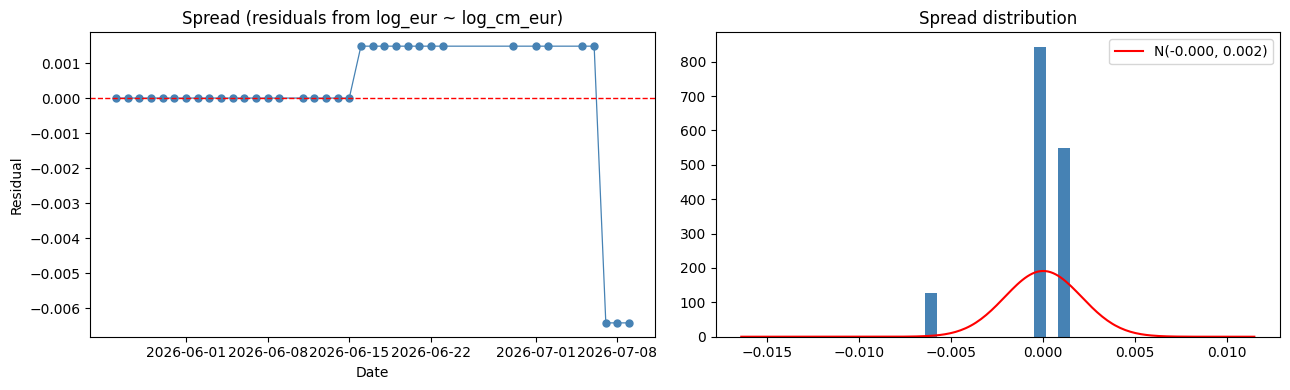


ADF on spread: stat=-0.7305, p=8.3869e-01
Spread stationary (cointegration confirmed): NO
Half-life of mean reversion: 7.2 days

OLS relationship (log_eur ~ log_cm_eur):
  β₀ = 0.1942,  β₁ = 0.1875
  β₁ = 0.1875 → β₁ ≠ 1 — asymmetric response


In [7]:
import statsmodels.formula.api as smf
from scipy.stats import norm

# Select the best available pair for the cointegrating regression.
# log_eur ~ log_cm_eur is the primary pair; log_eur ~ log_usd is the fallback.
best_pair = None
for s1_raw, s2_raw, label in [
    (log_eur, log_cm_eur, "log_eur ~ log_cm_eur"),
    (log_eur, log_usd, f"log_eur ~ log_usd ({usd_col})"),
]:
    df_c = pd.DataFrame({"log_s1": s1_raw, "log_s2": s2_raw}).dropna()
    if len(df_c) >= 3:
        best_pair = (df_c, label)
        break

if best_pair is None:
    print("No shared observations available. Section 3 skipped.")

else:
    df_coint, pair_label = best_pair
    n_pair = len(df_coint)
    print(f"Pair: {pair_label}  (n={n_pair})")

    if n_pair < 20:
        # OLS on n<20 points produces degenerate output (R²=NaN, AIC=−inf, BIC=−inf)
        # and triggers multiple RuntimeWarnings — skip entirely until data accumulates.
        rerun_date = (market.index.max() + pd.Timedelta(days=20 - n_pair)).date()
        print(
            f"\n⚠  n={n_pair} < 20 — OLS requires ≥20 observations for interpretable results."
        )
        print(
            f"   Section skipped. Re-run when ≥20 daily snapshots are available (~{rerun_date}).\n"
        )
        print("Expected output at ≥20 days:")
        print("  OLS summary: β₀, β₁, R², AIC, BIC")
        print("  Spread plot: residuals from log_eur ~ log_cm_eur")
        print("  ADF on spread: confirms cointegration if p < 0.05")
        print("  Half-life of mean reversion: −ln(2) / β₁  (days)")
        gold_connection.close()

    else:
        model = smf.ols("log_s1 ~ log_s2", data=df_coint).fit()
        print(model.summary())

        # Residuals from the cointegrating OLS form the stationary spread.
        # If the spread is truly stationary (ADF confirms), it can serve as a feature
        # in an Error Correction Model — it encodes how far the pair has deviated from
        # its long-run equilibrium.
        spread = model.resid

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

        ax1.plot(
            spread.index,
            spread.values,
            "o-",
            color="steelblue",
            linewidth=0.9,
            markersize=5,
        )
        ax1.axhline(0, color="red", linestyle="--", linewidth=1)
        ax1.set_title(f"Spread (residuals from {pair_label})")
        ax1.set_xlabel("Date")
        ax1.set_ylabel("Residual")

        ax2.hist(
            spread.values,
            bins=max(5, n_pair // 3),
            color="steelblue",
            edgecolor="none",
            density=True,
        )
        x = np.linspace(spread.min() - 0.01, spread.max() + 0.01, 200)
        ax2.plot(
            x,
            norm.pdf(x, spread.mean(), max(spread.std(), 1e-6)),
            "r-",
            linewidth=1.5,
            label=f"N({spread.mean():.3f}, {spread.std():.3f})",
        )
        ax2.set_title("Spread distribution")
        ax2.legend()

        plt.tight_layout()
        plt.show()

        # ADF on the spread confirms cointegration — only reliable at n≥20.
        adf_stat, adf_p, *_ = adfuller(spread)
        print(f"\nADF on spread: stat={adf_stat:.4f}, p={adf_p:.4e}")
        print(
            f"Spread stationary (cointegration confirmed): {'YES' if adf_p < 0.05 else 'NO'}"
        )

        # Half-life of mean reversion: how many days for the spread to decay by half.
        # Estimated via OLS: Δspread = β × spread_{t-1} + ε; half-life = −ln(2)/β.
        delta = spread.diff().dropna()
        lagged = spread.shift(1).loc[delta.index]
        X = sm.add_constant(lagged.values)
        reg_hl = sm.OLS(delta.values, X).fit()
        beta_hl = reg_hl.params[1]
        if beta_hl < 0:
            half_life = -np.log(2) / beta_hl
            print(f"Half-life of mean reversion: {half_life:.1f} days")
        else:
            print(f"Half-life: β={beta_hl:.4f} ≥ 0 — no mean reversion")

        beta0 = model.params["Intercept"]
        beta1 = model.params["log_s2"]
        near_unity = abs(beta1 - 1.0) < 0.05
        print(f"\nOLS relationship ({pair_label}):")
        print(f"  β₀ = {beta0:.4f},  β₁ = {beta1:.4f}")
        print(
            f"  β₁ = {beta1:.4f} → {'near-unity (markets move 1:1)' if near_unity else 'β₁ ≠ 1 — asymmetric response'}"
        )

In [8]:
gold_connection.close()

## 📋 Final Conclusions

```
PRE-CONDITION
──────────────────────────────────────────────────────────────────────────────
Log-price series are I(1) (from 02_stationarity, re-run at n=36 snapshots):
  Log-returns are CONFIRMED I(0) (ADF p=0.0000, KPSS p=0.1000 — both agree).
  Log-price LEVELS remain AMBIGUOUS: ADF fails to reject a unit root
  (p=0.9332, consistent with I(1)) but KPSS also fails to reject stationarity
  (p=0.0785); the combined classifier therefore does not commit to I(0)/I(1).
  Cointegration below is run on log-price LEVELS, where the I(1) precondition
  is only provisionally (not formally) supported.

DATA AVAILABILITY
──────────────────────────────────────────────────────────────────────────────
n days EUR Scryfall:     36  (2026-05-26 – 2026-07-09; min. 20 required for Engle-Granger — MET)
n days Cardmarket EUR:   36
n days USD TCGPlayer:    36  (used as the USD source; USD Scryfall also 36 days)

SPREAD STATISTICS (EUR Scryfall vs Cardmarket EUR, n=36)
──────────────────────────────────────────────────────────────────────────────
Spread log1p(EUR_Scryfall) − log1p(Cardmarket_EUR):
  mean = 0.0029  (Scryfall median is slightly higher than Cardmarket)
  std  = 0.0039
  min  = 0.0000, max = 0.0079
  % days with spread >10%: 0.0%  (spread is small and tightly bounded)

OLS relationship (log_eur ~ log_cm_eur, n=36):
  β₀ = 0.1942 (p<0.001),  β₁ = 0.1875 (p=0.044)
  R² = 0.114, F-statistic = 4.359 (Prob F = 0.0444)
  β₁ = 0.1875 → β₁ ≠ 1 (far from unity) — asymmetric response; Cardmarket EUR
  explains only a small share of Scryfall EUR variation in this regression.

ENGLE-GRANGER TEST RESULTS (n=36 for all pairs)
──────────────────────────────────────────────────────────────────────────────
EUR Scryfall ~ Cardmarket EUR:      t=-0.8138, p=0.9329  →  NOT cointegrated
EUR Scryfall ~ USD (tcgplayer_usd): t=-inf,    p=0.0000  →  flagged YES, but
  statsmodels raised a CollinearityWarning ("y0 and y1 are (almost) perfectly
  colinear. Cointegration test is not reliable in this case.") — this result
  is NOT trustworthy as stated; the near-perfect collinearity likely reflects
  EUR and USD tracking the same underlying market almost 1:1 rather than a
  genuine cointegrating relationship with independent variation.
Cardmarket EUR ~ USD (tcgplayer_usd): t=-1.3903, p=0.8008  →  NOT cointegrated

ADF ON SPREAD (log_eur ~ log_cm_eur residuals)
──────────────────────────────────────────────────────────────────────────────
ADF stat = -0.7305, p = 8.3869e-01
Spread stationary (cointegration confirmed): NO
Half-life of mean reversion: 7.2 days (computed from the AR(1) fit on the
  spread; not meaningful as a cointegration statement since the spread itself
  was not confirmed stationary by the ADF test above)

MODEL IMPLICATIONS
──────────────────────────────────────────────────────────────────────────────
Spread as feature (EUR − CM_EUR):  NOT SUPPORTED — Engle-Granger and ADF both
  fail to confirm cointegration between EUR Scryfall and Cardmarket EUR at
  n=36; do not add this spread as a mean-reverting feature yet.
Error Correction Model:            NOT SUPPORTED for the EUR~Cardmarket pair.
Cross-validation EUR↔USD:          The EUR~USD Engle-Granger result is
  statistically "significant" but flagged unreliable by statsmodels due to
  near-perfect collinearity — treat as inconclusive, not as confirmation.

RETEST SCHEDULE
──────────────────────────────────────────────────────────────────────────────
n≥20 threshold for Engle-Granger/ADF: MET (n=36) — tests above are the final
  (non-provisional) results for this data window; no further retest is
  required purely for sample size. Re-run if the I(1) status of log-price
  levels is resolved differently in 02_stationarity, or once materially more
  history accumulates (e.g. to see whether the EUR~Cardmarket spread narrows
  or the OLS β₁ moves closer to 1).
```
